In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5


In [3]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

In [4]:
rng = np.random.default_rng(1)

### Photoswitching fingerprint

In [5]:
num_simulations = 500
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({13:1e1})
transition_set.finalize()
bleaching_times_1e1 = []
early_bleach_1e1 = 0
no_bleach_1e1 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 1e-3*300:
            bleaching_times_1e1.append(simulation.time_series[-2])
        else:
            early_bleach_1e1 += 1
    else:
        no_bleach_1e1 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [6]:
rel_all_events_discard_bl_1e1 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [7]:
num_simulations = 500
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({13:1e2})
transition_set.finalize()
bleaching_times_1e2 = []
early_bleach_1e2 = 0
no_bleach_1e2 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 1e-3*300:
            bleaching_times_1e2.append(simulation.time_series[-2])
        else:
            early_bleach_1e2 += 1
    else:
        no_bleach_1e2 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [8]:
rel_all_events_discard_bl_1e2 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [9]:
num_simulations = 1500

all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({13:1e3})
transition_set.finalize()
bleaching_times_1e3 = []
early_bleach_1e3 = 0
no_bleach_1e3 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 1e-3*300:
            bleaching_times_1e3.append(simulation.time_series[-2])
        else:
            early_bleach_1e3 += 1
    else:
        no_bleach_1e3 += + 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [10]:
rel_all_events_discard_bl_1e3 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [22]:
num_simulations = 15000
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({13:1e4})
transition_set.finalize()
bleaching_times_1e4 = []
no_bleach_1e4 = 0
early_bleach_1e4 = 0
for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 300*1e-3:
            bleaching_times_1e4.append(simulation.time_series[-2])
        else:
            early_bleach_1e4 += 1
    else:
        no_bleach_1e4 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [23]:
rel_all_events_discard_bl_1e4 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [24]:
from scipy.stats import expon
def estimate_lambda(bleaching_times, no_bleach):
    t_b_max = np.max(bleaching_times)
    p = len(bleaching_times) / (len(bleaching_times) + no_bleach)
    if p == 1:
        lambda_ = 1/np.mean(bleaching_times)
    else:
        lambda_ = - np.log(1 - p) / t_b_max


    return lambda_

In [25]:
x = np.linspace(0, 300, 299701)
lambda_1e1 = estimate_lambda(bleaching_times_1e1, no_bleach_1e1)
lambda_1e2 = estimate_lambda(bleaching_times_1e2, no_bleach_1e2)
lambda_1e3 = estimate_lambda(bleaching_times_1e3, no_bleach_1e3)
lambda_1e4 = estimate_lambda(bleaching_times_1e4, no_bleach_1e4)
cdf_1e1 = expon.cdf(x=x, scale=1/lambda_1e1)
cdf_1e2 = expon.cdf(x=x, scale=1/lambda_1e2)
cdf_1e3 = expon.cdf(x=x, scale=1/lambda_1e3)
cdf_1e4 = expon.cdf(x=x, scale=1/lambda_1e4)
cdf_1e1 /= cdf_1e1[-1]
cdf_1e2 /= cdf_1e2[-1]
cdf_1e3 /= cdf_1e3[-1]
cdf_1e4 /= cdf_1e4[-1]

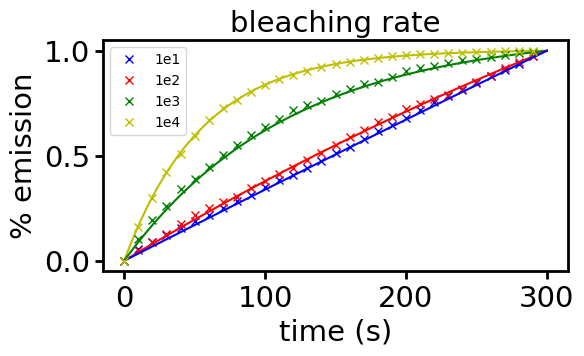

In [27]:
ax = fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_bl_1e1[::10000]], 
                        label='1e1', marker='x', linestyle='')
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_bl_1e2[::10000]], 
                    marker='x', linestyle='', axes=ax[0], color='r', label='1e2')
fi.universal_figure(data=[x, cdf_1e4], 
                    axes=ax[0], color='y')
fi.universal_figure(data=[x, cdf_1e3], 
                    axes=ax[0], color='g')
fi.universal_figure(data=[x, cdf_1e2],
                    axes=ax[0], color='r')
fi.universal_figure(data=[x, cdf_1e1],
                    axes=ax[0], color='b', legend=True)
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_bl_1e3[::10000]],
                    axes=ax[0], color='g', label='1e3', linestyle='', marker='x')
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_bl_1e4[::10000]],
                    axes=ax[0], color='y', label='1e4', marker='x', linestyle='',
                    title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True)
fig = mi.get_figure(ax)
fig.savefig("bl_rate_cum_locs.svg")